In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
from __future__ import print_function
import os, sys, time, datetime, json, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import clone_model
from keras.models import Sequential
from keras.layers import Dense, Activation, PReLU
from keras.optimizers import SGD , Adam, RMSprop
import matplotlib.pyplot as plt
from TreasureMaze import TreasureMaze
from GameExperience import GameExperience
%matplotlib inline

2025-11-21 22:57:53.049997: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-21 22:57:53.066447: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-21 22:57:53.816338: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-21 22:57:54.029826: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763765874.415396     248 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763765874.47

In [3]:
def build_model(maze, num_actions):
    """Build a simple DQN model.
    - Input: flattened maze state of length maze.size
    - Output: Q-values for each action (num_actions)
    """
    model = Sequential()
    # Input layer: one neuron per maze cell
    model.add(Dense(maze.size, input_shape=(maze.size,)))
    model.add(PReLU())

    # Hidden layer
    model.add(Dense(maze.size))
    model.add(PReLU())

    # Output layer: one neuron per action
    model.add(Dense(num_actions))

    # Compile with Adam optimizer and MSE loss
    model.compile(optimizer='adam', loss='mse')
    return model

In [4]:
maze = np.array([
    [ 1.,  0.,  1.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  0.,  1.,  1.,  1.,  0.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  0.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  0.,  1.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  0.,  1.,  0.,  0.,  0.],
    [ 1.,  1.,  1.,  0.,  1.,  1.,  1.,  1.],
    [ 1.,  1.,  1.,  1.,  0.,  1.,  1.,  1.]
])

In [5]:
def show(qmaze):
    plt.grid('on')
    nrows, ncols = qmaze.maze.shape
    ax = plt.gca()
    ax.set_xticks(np.arange(0.5, nrows, 1))
    ax.set_yticks(np.arange(0.5, ncols, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    canvas = np.copy(qmaze.maze)
    for row,col in qmaze.visited:
        canvas[row,col] = 0.6
    pirate_row, pirate_col, _ = qmaze.state
    canvas[pirate_row, pirate_col] = 0.3   # pirate cell
    canvas[nrows-1, ncols-1] = 0.9 # treasure cell
    img = plt.imshow(canvas, interpolation='none', cmap='gray')
    return img

In [6]:
LEFT = 0
UP = 1
RIGHT = 2
DOWN = 3


# Exploration factor
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
patience = 10

# Actions dictionary
actions_dict = {
    LEFT: 'left',
    UP: 'up',
    RIGHT: 'right',
    DOWN: 'down',
}

num_actions = len(actions_dict)

reward= -0.04


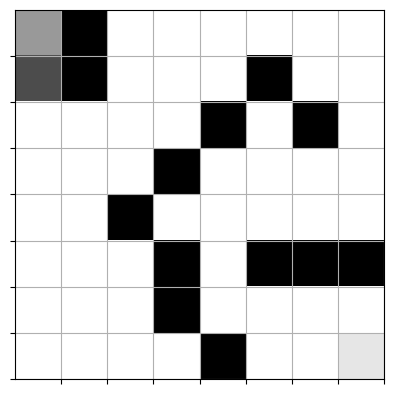

In [7]:
qmaze = TreasureMaze(maze)
canvas, reward, game_over = qmaze.act(DOWN)
print("reward=", reward)
show(qmaze)

In [8]:
def play_game(model, qmaze, pirate_cell, max_steps=None):
    qmaze.reset(pirate_cell)
    envstate = qmaze.observe()
    steps = 0
    if max_steps is None:
        max_steps = qmaze.maze.size * 4  # safety cutoff

    while steps < max_steps:
        state = np.asarray(envstate, dtype=np.float32)
        if state.ndim == 1:
            state = np.expand_dims(state, axis=0)

        q_values = model(state, training=False).numpy()
        action = np.argmax(q_values[0])

        envstate, reward, game_status = qmaze.act(action)
        steps += 1

        if game_status == 'win':
            return True
        elif game_status == 'lose':
            return False

    return False  # timed out with no result

In [9]:
def completion_check(model, maze_or_qmaze, max_steps=None):
    # Accept either raw numpy maze or TreasureMaze instance
    if isinstance(maze_or_qmaze, TreasureMaze):
        qmaze = maze_or_qmaze
    else:
        qmaze = TreasureMaze(maze_or_qmaze)

    for cell in qmaze.free_cells:
        if not qmaze.valid_actions(cell):
            continue
        if not play_game(model, qmaze, cell, max_steps=max_steps):
            return False
    return True

In [10]:
def build_model(maze):
    model = Sequential()
    model.add(Dense(maze.size, input_shape=(maze.size,)))
    model.add(PReLU())
    model.add(Dense(maze.size))
    model.add(PReLU())
    model.add(Dense(num_actions))
    model.compile(optimizer='adam', loss='mse')
    return model

In [11]:
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam()

@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        q_values = model(x, training=True)
        loss = loss_fn(y, q_values)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

E0000 00:00:1763765883.490466     248 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1763765883.495270     248 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [12]:
def qtrain(model, maze, **opt):
    """
    Train a DQN agent on the TreasureMaze environment.

    Parameters
    ----------
    model : keras.Model
        Q-network that maps states -> Q-values.
    maze : np.ndarray
        Grid definition for the environment.
    opt : dict
        Optional training hyperparameters, e.g.:
        - n_epoch or epochs: number of training epochs
        - max_memory: replay memory size
        - data_size: batch size sampled from replay
        - target_update_freq: how often to sync target network
    """
    global epsilon

    # Number of epochs (support both 'n_epoch' and 'epochs')
    n_epoch = opt.get("n_epoch", opt.get("epochs", 15000))

    # Maximum memory to store episodes
    max_memory = opt.get("max_memory", 1000)

    # Maximum data size for training
    data_size = opt.get("data_size", 50)

    # Frequency of target network updates
    target_update_freq = opt.get("target_update_freq", 50)

    # Start time
    start_time = datetime.datetime.now()

    # Construct environment/game from numpy array: maze
    qmaze = TreasureMaze(maze)

    # Target Network (not strictly required but useful; we keep it for future use)
    target_model = clone_model(model)
    target_model.set_weights(model.get_weights())

    # Initialize experience replay object
    experience = GameExperience(model, max_memory=max_memory)

    win_history = []  # history of win/lose game
    hsize = qmaze.maze.size // 2  # history window size
    win_rate = 0.0
    n_episodes = 0

    for epoch in range(n_epoch):
        loss = 0.0

        # Reset the environment at a random starting cell
        agent_cell = random.choice(qmaze.free_cells)
        qmaze.reset(agent_cell)

        # Initial environment state
        env_state = qmaze.observe()
        game_status = "not_over"

        # Play one full episode
        while game_status == "not_over":
            previous_envstate = env_state

            # ε-greedy action selection
            if np.random.rand() < epsilon:
                # Exploration: random valid action
                action = random.choice(qmaze.valid_actions())
            else:
                # Exploitation: best Q-value from the model
                state = np.asarray(env_state, dtype=np.float32)
                if state.ndim == 1:
                    state = np.expand_dims(state, axis=0)
                q_values = model(state, training=False).numpy()
                action = int(np.argmax(q_values[0]))

            # Environment step
            env_state, reward, game_status = qmaze.act(action)

            # Track wins and losses (once per episode outcome)
            if game_status == "win":
                win_history.append(1)
            elif game_status == "lose":
                win_history.append(0)

            # Store the episode in the Experience replay object
            episode = [previous_envstate, action, reward, env_state, game_status]
            experience.remember(episode)

            # Train neural network model and evaluate loss
            inputs, targets = experience.get_data(data_size=data_size)
            batch_loss = train_step(inputs, targets)

            # Convert Tensor loss to float for accumulation/printing
            try:
                batch_loss_val = float(batch_loss.numpy())
            except AttributeError:
                batch_loss_val = float(batch_loss)
            loss += batch_loss_val

        n_episodes += 1

        # Win rate over last hsize episodes
        win_rate = (
            sum(win_history[-hsize:]) / hsize
            if len(win_history) >= hsize
            else 0.0
        )

        # Print stats for this epoch
        dt = datetime.datetime.now() - start_time
        t = format_time(dt.total_seconds())
        print(
            "Epoch: {:03d}/{:d} | Loss: {:.4f} | Episodes: {:d} | "
            "Win count: {:d} | Win rate: {:.3f} | time: {}".format(
                epoch,
                n_epoch - 1,
                loss,
                n_episodes,
                sum(win_history),
                win_rate,
                t,
            )
        )

        # Periodically sync target network weights (kept for future use)
        if epoch % target_update_freq == 0:
            target_model.set_weights(model.get_weights())

        # Adjust epsilon (exploration rate)
        if win_rate > 0.9:
            epsilon = 0.05
        else:
            epsilon = max(epsilon * epsilon_decay, epsilon_min)

        # Early stopping: solved if nearly perfect win rate and maze fully solved
        if win_rate >= 0.999 and completion_check(model, maze):
            print(f"Reached ~100% win rate at epoch {epoch}")
            break

    total_time = format_time((datetime.datetime.now() - start_time).total_seconds())
    print("Training complete in:", total_time)


# This is a small utility for printing readable time strings:
def format_time(seconds):
    if seconds < 400:
        s = float(seconds)
        return "%.1f seconds" % (s,)
    elif seconds < 4000:
        m = seconds / 60.0
        return "%.2f minutes" % (m,)
    else:
        h = seconds / 3600.0
        return "%.2f hours" % (h,)


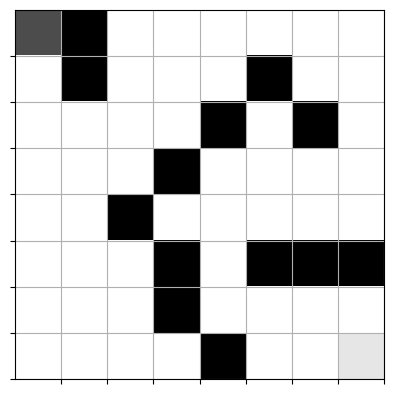

In [13]:
qmaze = TreasureMaze(maze)
show(qmaze)

In [18]:
model = build_model(maze)
qtrain(model, maze, epochs=1000, max_memory=8*maze.size, data_size=32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

KeyboardInterrupt: 

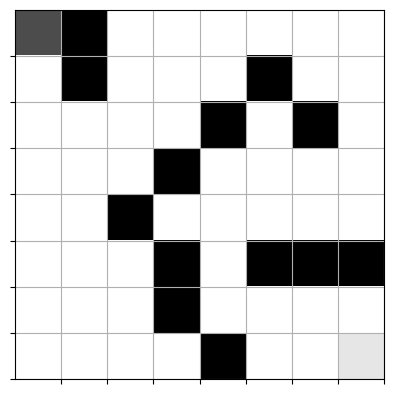

In [15]:
completion_check(model, qmaze)
show(qmaze)

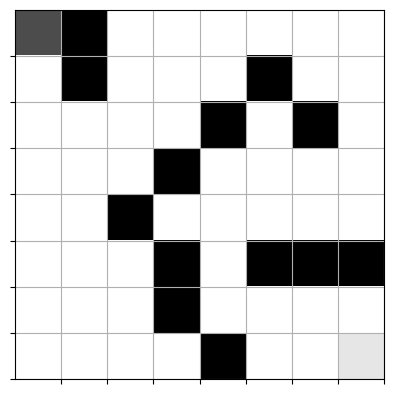

In [16]:
pirate_start = (0, 0)
play_game(model, qmaze, pirate_start)
show(qmaze)